# User Engagement Analysis

**Goals:**
1. Aggregate engagement metrics per customer (session frequency, duration, traffic)
2. Top 10 customers per metric
3. Normalize + k-means (k=3) → engagement clusters
4. Cluster stats on **non-normalized** metrics
5. Top 10 engaged users per application
6. Plot top 3 applications
7. Elbow method for optimal k

> Logic in `src/tellco_user_analytics/analysis/engagement.py`

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root / "src") not in sys.path:
    sys.path.insert(0, str(project_root / "src"))

from tellco_user_analytics.data.loader import load_xdr_sessions
from tellco_user_analytics.analysis.engagement import (
    ENGAGEMENT_FEATURES,
    aggregate_engagement,
    top_customers_per_metric,
    fit_engagement_clusters,
    cluster_summary_stats,
    top_users_per_application,
    top_applications_by_traffic,
    elbow_analysis,
    suggest_elbow_k,
)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## 1. Load data & aggregate engagement metrics

In [2]:
sessions = load_xdr_sessions()
engagement = aggregate_engagement(sessions)
print(f"Customers: {len(engagement):,}")
engagement.head()

Customers: 106,856


,customer_id,session_count,total_duration_ms,total_traffic_bytes,Social Media,Google,Email,Youtube,Netflix,Gaming,Other
0,3.360100e+10,1,116720.0,8.786906e+08,2232135.0,4389005.0,1331362.0,21624548.0,27180981.0,8.124587e+08,386570872.0
1,3.360100e+10,1,181230.0,1.568596e+08,2660565.0,5334863.0,3307781.0,12432223.0,11221763.0,1.197501e+08,281710071.0
2,3.360100e+10,1,134969.0,5.959665e+08,3195623.0,3443126.0,3205380.0,21333570.0,19353900.0,5.388277e+08,501693672.0
3,3.360101e+10,1,49878.0,4.223207e+08,280294.0,9678493.0,2284670.0,6977321.0,1942092.0,3.911261e+08,35279702.0
4,3.360101e+10,2,37104.0,1.457411e+09,2912542.0,18499616.0,3305469.0,41533002.0,49201724.0,1.314798e+09,804804484.0


## 2. Top 10 customers per engagement metric

In [3]:
top10 = top_customers_per_metric(engagement, n=10)
for metric, table in top10.items():
    print(f"\n=== Top 10 by {metric} ===")
    display(table)


=== Top 10 by session_count ===


,customer_id,session_count
0,3.362632e+10,18
1,3.361489e+10,17
2,3.362578e+10,17
3,3.365973e+10,16
4,3.367588e+10,15
5,3.376054e+10,15
6,3.366716e+10,13
7,3.360313e+10,12
8,3.360452e+10,12
9,3.362708e+10,12



=== Top 10 by total_duration_ms ===


,customer_id,total_duration_ms
0,3.362578e+10,18553754.0
1,3.361489e+10,9966898.0
2,3.376054e+10,9279434.0
3,3.362632e+10,8791927.0
4,3.366716e+10,8744914.0
5,3.366284e+10,6614270.0
6,3.366469e+10,6288730.0
7,3.360313e+10,6287761.0
8,3.366746e+10,5649882.0
9,3.376041e+10,5321667.0



=== Top 10 by total_traffic_bytes ===


,customer_id,total_traffic_bytes
0,3.361489e+10,8.846226e+09
1,3.376054e+10,8.514774e+09
2,3.362578e+10,8.499621e+09
3,3.362632e+10,7.971167e+09
4,3.367588e+10,7.891111e+09
5,3.365973e+10,7.705863e+09
6,3.366646e+10,7.308501e+09
7,3.376041e+10,7.132371e+09
8,3.366471e+10,6.872018e+09
9,3.369879e+10,6.540899e+09


## 3. K-means clustering (k=3) on normalized engagement metrics

**Why normalize?** Session count, duration, and bytes are on different scales. `sklearn.preprocessing.Normalizer` puts each user on a unit sphere so k-means compares *patterns* not raw magnitude.

session_count                   total_duration_ms              \
                  min max  mean     sum               min         max   
cluster                                                                 
0                   0  11  1.41  126381            7142.0   2927785.0   
1                   0  18  1.30   20203           19764.0   9966898.0   
2                   1  17  1.09    1922           81644.0  18553754.0   

                                 total_traffic_bytes                \
              mean           sum                 min           max   
cluster                                                              
0        127215.75  1.139077e+10          46047479.0  6.872018e+09   
1        236585.91  3.680094e+09          33249009.0  8.846226e+09   
2        310995.02  5.479732e+08          33575840.0  8.499621e+09   

                                     
                 mean           sum  
cluster                              
0        7.597007e+08  6.802284e+13  
1        3.559074e+08  5.536140e+12  
2        1.557715e+08  2.744693e+11

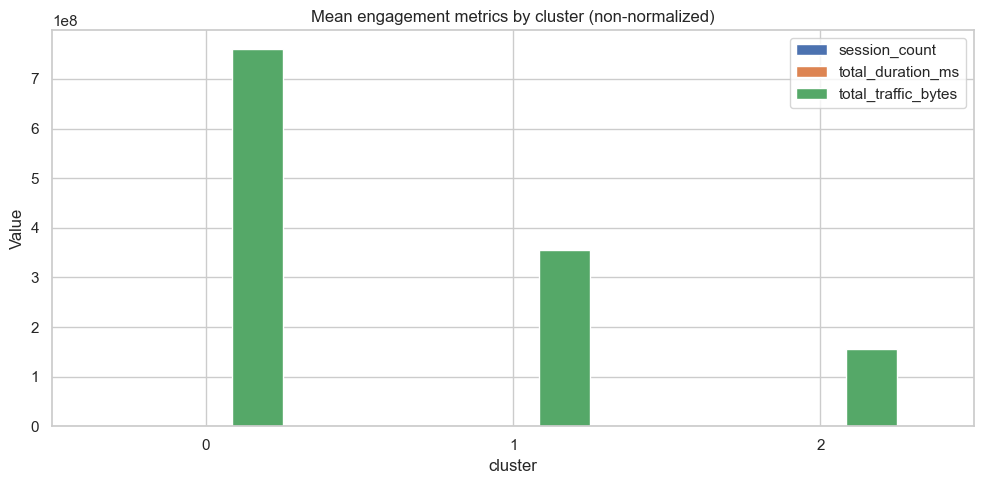

In [4]:
cluster_result = fit_engagement_clusters(engagement, k=3)
clustered = cluster_result.data
summary = cluster_summary_stats(clustered)

display(summary)

# Visualise cluster profiles (non-normalized means)
cluster_means = clustered.groupby("cluster")[ENGAGEMENT_FEATURES].mean()
cluster_means.plot(kind="bar", figsize=(10, 5), rot=0)
plt.title("Mean engagement metrics by cluster (non-normalized)")
plt.ylabel("Value")
plt.tight_layout()
plt.show()

### Cluster interpretation

Clusters were built on **L2-normalized** engagement (session count, duration, traffic mix), then profiled here in **raw units**. Session counts are ~1 for all groups, so separation is mainly **duration vs traffic**, not visit frequency.

| Cluster | Share | Typical profile | Business action |
|---------|-------|-----------------|-----------------|
| **0 — High-volume** | ~84% (89.5k users) | Highest avg traffic (~**760 MB**), shortest avg duration (~**127k ms**). Short, data-heavy sessions — likely burst downloads / gaming. | Default mass-market segment. Optimise capacity for peak throughput; standard data bundles and fair-use policies. |
| **1 — Balanced** | ~15% (15.6k users) | Mid duration (~**237k ms**), mid traffic (~**356 MB**). Moderate time-on-network with steady usage. | Upsell larger data bundles and cross-sell streaming/gaming add-ons; good target for loyalty offers. |
| **2 — Long-session** | ~2% (1.8k users) | Longest avg duration (~**311k ms**), lowest avg traffic (~**156 MB**). Stay connected longer but consume less data per session. | Retain with time-based plans or unlimited low-speed tiers; investigate app mix (background / messaging vs streaming). |

**Key takeaway:** There is no single "low / medium / high" ladder on all metrics. Cluster 0 is the **traffic workhorse** (most users, most bytes), while cluster 2 is a small **duration-focused** niche — different levers for product and network planning.

## 4. Top 10 engaged users per application

In [ ]:
top_per_app = top_users_per_application(engagement, n=10)
for app, table in list(top_per_app.items())[:3]:  # show first 3; full dict available
    print(f"\n=== Top 10 — {app} ===")
    display(table)

## 5. Top 3 most used applications (network-wide)

In [ ]:
top3_apps = top_applications_by_traffic(engagement, n=3)
display(top3_apps.to_frame("total_bytes"))

fig, ax = plt.subplots(figsize=(8, 5))
top3_apps.plot(kind="bar", ax=ax, color=["#4C72B0", "#55A868", "#C44E52"])
ax.set_title("Top 3 applications by total user traffic")
ax.set_ylabel("Bytes")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

## 6. Elbow method — optimal k

Plot inertia (within-cluster sum of squares) vs k. The "elbow" is where adding clusters yields diminishing returns.

In [ ]:
elbow_df = elbow_analysis(engagement, k_range=range(1, 11))
optimal_k = suggest_elbow_k(elbow_df)
print(f"Suggested optimal k (elbow): {optimal_k}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(elbow_df["k"], elbow_df["inertia"], marker="o", linewidth=2)
ax.axvline(optimal_k, color="red", linestyle="--", label=f"Suggested k={optimal_k}")
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Inertia (WCSS)")
ax.set_title("Elbow method for engagement clustering")
ax.legend()
plt.tight_layout()
plt.show()

# Optional: refit with elbow-suggested k
if optimal_k != 3:
    elbow_clusters = fit_engagement_clusters(engagement, k=optimal_k)
    display(cluster_summary_stats(elbow_clusters.data))